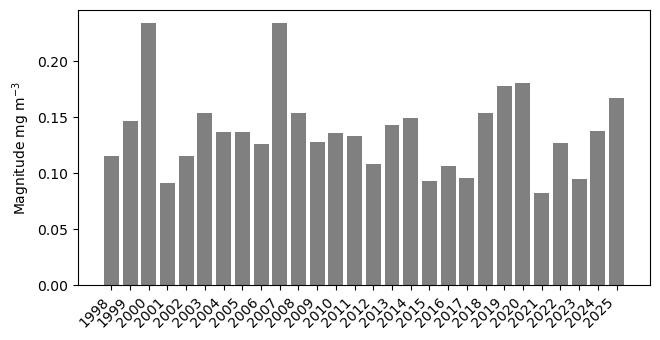

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# df = pd.read_csv('/home/jamesash/projects/climate/data/summary_statistics/bloom_summary_2p_1mad_20260418.csv')
# df = pd.read_csv('/home/jamesash/projects/climate/data/summary_statistics/bloom_summary_exp_2p_1mad_20260423.csv')
df = pd.read_csv('/home/jamesash/projects/climate/data/summary_statistics/bloom_summary_2p_1mad_20260609.csv')

df["year"] = pd.to_datetime(df["start"]).dt.year

fig, ax = plt.subplots(figsize=(6.7, 3.5))
ax.bar(df["year"], df["magnitude"], color="grey", edgecolor="none")

# ax.set_xlabel("Year")
ax.set_ylabel("Magnitude mg m$^{-3}$")
# ax.set_title("Magnitude by Year")
ax.set_xticks(df["year"])
ax.set_xticklabels(df["year"], rotation=45, ha="right")

plt.tight_layout()
# plt.savefig('../../figures/bloom_magnitude_1mad_20260418.png', format='png', bbox_inches='tight', dpi=600)
plt.show()

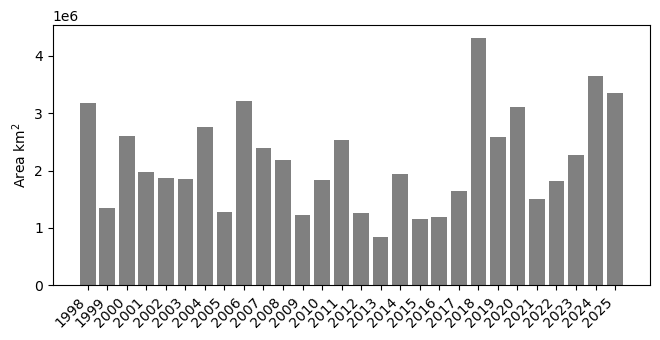

In [24]:
# df["true_area_km2"] = df["max_area_km2"] + (df["max_area_km2"] * df["cloud_pct"]/100)
df["true_area_km2"] = df["max_area_km2"] / (1 - df["cloud_pct"]/100)

fig, ax = plt.subplots(figsize=(6.7, 3.5))
ax.bar(df["year"], df["true_area_km2"], color="grey", edgecolor="none")

# ax.set_xlabel("Year")
ax.set_ylabel("Area km$^{2}$")
#ax.set_title("Magnitude by Year")
ax.set_xticks(df["year"])
ax.set_xticklabels(df["year"], rotation=45, ha="right")

plt.tight_layout()
# plt.savefig('../../figures/bloom_area_1mad_20260330.pdf', format='pdf', bbox_inches='tight', dpi=600)
# plt.savefig('../../figures/bloom_area_1mad_20260330.png', format='png', bbox_inches='tight', dpi=600)
plt.show()

In [4]:
df.columns

Index(['start', 'end', 'center_date', 'center_lat', 'center_lon', 'magnitude',
       'mag_q90', 'mag_q99', 'max_area_km2', 'max_area_date', 'cloud_pct',
       'year', 'true_area_km2'],
      dtype='object')

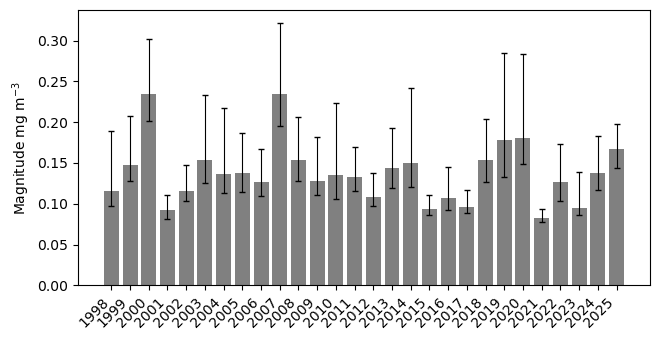

In [25]:
mag_lower = df["magnitude"] - df["mag_q90"]
mag_upper = df["mag_q99"] - df["magnitude"]

fig, ax = plt.subplots(figsize=(6.7, 3.5))
ax.bar(df["year"], df["magnitude"], color="grey", edgecolor="none")
ax.errorbar(df["year"], df["magnitude"],
            yerr=[mag_lower, mag_upper],
            fmt='none', ecolor='black', capsize=2, linewidth=0.8)
ax.set_ylabel("Magnitude mg m$^{-3}$")
ax.set_xticks(df["year"])
ax.set_xticklabels(df["year"], rotation=45, ha="right")
plt.tight_layout()
plt.savefig('../../figures/bloom_area_1mad_bars_20260909.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.savefig('../../figures/bloom_area_1mad_bars_20260309.png', format='png', bbox_inches='tight', dpi=600)
plt.show()

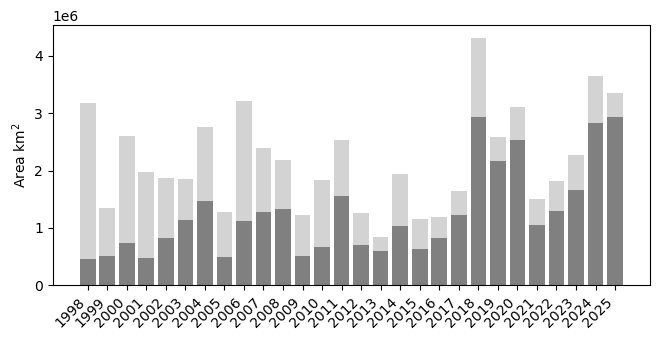

In [26]:
# ---- Figure 2: Area with cloud-correction error bars ----
# Lower bound = observed area, upper bound = cloud-corrected area
# Asymmetric error: bar shows corrected, whisker extends down to observed
#area_err_lower = df["true_area_km2"] - df["max_area_km2"]  # correction amount
#area_err_upper = np.zeros(len(df))                          # no upward error

fig, ax = plt.subplots(figsize=(6.7, 3.5))

ax.bar(df["year"], df["true_area_km2"], color="lightgrey", edgecolor="none")
ax.bar(df["year"], df["max_area_km2"], color="grey", edgecolor="none")

# ax.errorbar(df["year"], df["true_area_km2"],
#             #yerr=[area_err_lower, area_err_upper],
#             fmt='none', ecolor='black', capsize=2, linewidth=0.8)
ax.set_ylabel("Area km$^{2}$")
ax.set_xticks(df["year"])
ax.set_xticklabels(df["year"], rotation=45, ha="right")
plt.tight_layout()
# plt.savefig('../../figures/bloom_area_1mad_20260609.pdf', format='pdf', bbox_inches='tight', dpi=600)
# plt.savefig('../../figures/bloom_area_1mad_20260609.png', format='png', bbox_inches='tight', dpi=600)
plt.show()

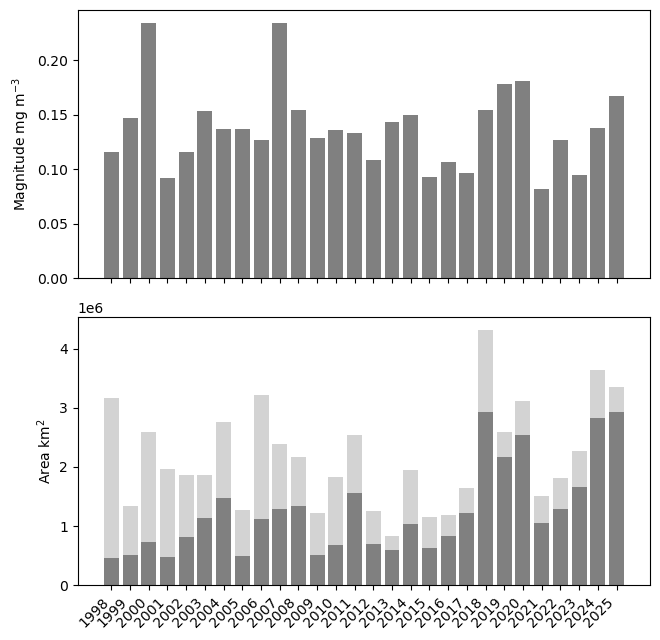

In [28]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.7, 6.5), sharex=True)

# ---- Panel 1: Magnitude ----
mag_lower = df["magnitude"] - df["mag_q90"]
mag_upper = df["mag_q99"] - df["magnitude"]

ax1.bar(df["year"], df["magnitude"], color="grey", edgecolor="none")
# ax1.errorbar(df["year"], df["magnitude"],
#              yerr=[mag_lower, mag_upper],
#              fmt='none', ecolor='black', capsize=2, linewidth=0.8)
ax1.set_ylabel("Magnitude mg m$^{-3}$")

# ---- Panel 2: Area ----
ax2.bar(df["year"], df["true_area_km2"], color="lightgrey", edgecolor="none")
ax2.bar(df["year"], df["max_area_km2"], color="grey", edgecolor="none")
ax2.set_ylabel("Area km$^{2}$")

# Shared x-axis
ax2.set_xticks(df["year"])
ax2.set_xticklabels(df["year"], rotation=45, ha="right")

plt.tight_layout()
# plt.savefig('../../figures/bloom_mag_area_1mad_20260909.pdf', format='pdf', bbox_inches='tight', dpi=600)
# plt.savefig('../../figures/bloom_mag_area_1mad_20260909.png', format='png', bbox_inches='tight', dpi=600)
plt.show()

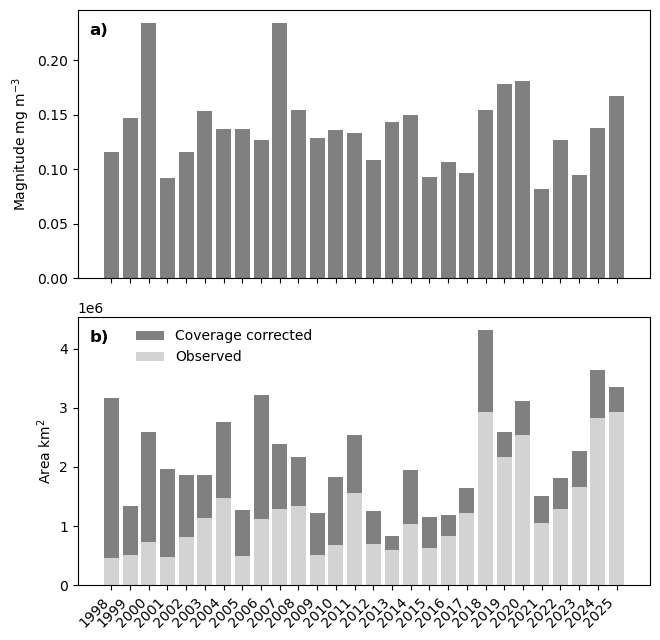

In [42]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.7, 6.5), sharex=True)

# ---- Panel 1: Magnitude ----
mag_lower = df["magnitude"] - df["mag_q90"]
mag_upper = df["mag_q99"] - df["magnitude"]

ax1.bar(df["year"], df["magnitude"], color="grey", edgecolor="none")
ax1.set_ylabel("Magnitude mg m$^{-3}$")
ax1.text(0.02, 0.95, 'a)', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='left')

# ---- Panel 2: Area ----
ax2.bar(df["year"], df["true_area_km2"], color="grey", edgecolor="none",
        label="Coverage corrected")
ax2.bar(df["year"], df["max_area_km2"], color="lightgrey", edgecolor="none",
        label="Observed")
ax2.set_ylabel("Area km$^{2}$")
ax2.text(0.02, 0.95, 'b)', transform=ax2.transAxes,
         fontsize=12, fontweight='bold', va='top', ha='left')
ax2.legend(fontsize=10, frameon=False, loc='upper left', bbox_to_anchor=(0.08, 1))

# Shared x-axis
ax2.set_xticks(df["year"])
ax2.set_xticklabels(df["year"], rotation=45, ha="right")

plt.tight_layout()
plt.savefig('../../figures/bloom_mag_area_1mad_20260610.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.savefig('../../figures/bloom_mag_area_1mad_20260610.png', format='png', bbox_inches='tight', dpi=600)
plt.show()